# Twitter Sentiment Analysis: Apple & Google Products
## Phase 4 Group 4 Project

---

## Summary

Social media platforms generate massive volumes of consumer opinion data every day. For technology companies like Apple and Google, understanding whether public discourse is positive, negative, or neutral is essential for protecting brand reputation, guiding product development, and informing marketing strategy. Manual analysis at this scale is infeasible, creating a clear need for automated sentiment classification systems.

This project develops a supervised Natural Language Processing (NLP) pipeline to classify the sentiment of approximately 9,000 tweets about Apple and Google products. The dataset, sourced from CrowdFlower via data.world, contains tweets human-labeled as positive, negative, or neutral. The class distribution is heavily imbalanced — neutral tweets represent roughly 60% of the data, positive tweets approximately 33%, and negative tweets only about 6%. This imbalance directly shaped our evaluation strategy, leading us to adopt weighted F1-score over accuracy as the primary metric.

Text preprocessing was performed using NLTK, with careful retention of negation terms to preserve sentiment-bearing context. Tweets were vectorized using TF-IDF with sublinear scaling, trigrams, and expanded vocabulary. Class imbalance was addressed through SMOTE oversampling within cross-validation folds to prevent data leakage. We evaluated models iteratively across multiple packages — scikit-learn (Logistic Regression, Naive Bayes, Random Forest, LinearSVC), XGBoost, and spaCy word embeddings — with hyperparameters tuned via GridSearchCV. Model interpretability was assessed using LIME for local explanations and SHAP for global feature importance analysis.

The final tuned model achieved strong weighted F1-score performance on the held-out test set, with the strongest classification on positive and neutral classes. The negative class remains the most challenging due to limited training examples. We discuss stakeholder implications, model limitations including dataset age and sarcasm detection, and recommend future work including transformer-based models and real-time deployment pipelines.

## 1. Introduction: Business Understanding


### The Real-World Problem

In today's digital landscape, companies like Apple and Google receive **thousands of mentions on social media every hour**. Manually reading and categorizing this volume of feedback is impossible. Yet understanding public sentiment is critical — a viral negative tweet about a product defect can escalate into a PR crisis within hours, while positive buzz around a product launch can be amplified for marketing advantage. **Companies need an automated, scalable way to monitor and classify sentiment in real-time.**

### Stakeholders and How They Would Use This Model

**Product Marketing Teams** Monitor sentiment during product launches (e.g., new iPhone, Google Pixel). Identify which features generate positive buzz and which receive criticism. Adjust messaging in real-time.

**Customer Support / CX Teams** Set up alerts for spikes in negative sentiment to proactively address widespread product issues before they escalate. Prioritize support resources.

**Product Development Teams** Analyze negative tweets to identify recurring complaints (e.g., battery life, software bugs). Feed insights into the product roadmap for future iterations.

**Executive Leadership / PR** Track overall brand health over time via sentiment dashboards. Compare sentiment between Apple vs. Google products. Prepare data-driven responses to media inquiries.

### Our Solution
We build an NLP classifier that can automatically categorize a tweet as **positive**, **negative**, or **neutral**  enabling stakeholders to process thousands of tweets per minute and power automated dashboards, alerts, and reports.

## 2. Setup and Imports

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import re
import warnings


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:

# NLP - NLTK
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Machine Learning - scikit-learn
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                      StratifiedKFold, cross_val_score)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score,
                              ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline


In [3]:

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 100)
sns.set_style('whitegrid')



## 3. Data Understanding

### 3.1 Data Source

The dataset comes from **CrowdFlower** (now Figure Eight / Appen) via [data.world](https://data.world/crowdflower/brands-and-product-emotions). It contains **9,093 tweets** collected during the 2011 South by Southwest (SXSW) conference in Austin, Texas. Each tweet was reviewed by human raters who assessed:

1. **Which brand or product** the tweet is directed at (e.g., iPhone, iPad, Google, Android)
2. **The sentiment** expressed toward that brand/product (Positive, Negative, Neutral, or "I can't tell")

### Why This Dataset Is Suitable

##### Criterion  Assessment 

 **Labeled data**  Human-annotated sentiment labels enable supervised classification — no need for unsupervised labeling heuristics
 
 **Real-world text**  Tweets are authentic social media posts with natural language patterns (abbreviations, hashtags, slang, sarcasm) 
 
 **Multiclass labels**  Positive/Negative/Neutral categories match real business needs for brand monitoring 
 
 **Relevant domain**  Apple and Google are among the world's most discussed brands — findings generalize to tech brand monitoring 
 
 **Manageable size**  ~9,000 tweets is large enough for classical ML models while remaining computationally feasible on local machines 

### Data Limitations (Identified Upfront)

1. **Temporal bias** — All tweets are from SXSW 2011. Language patterns, products (iPhone 4, iPad 1), and slang have changed dramatically. The model may not generalize to modern tweets.
2. **Event-specific context** — SXSW is a tech conference, so the audience skews tech-savvy and enthusiastic. Sentiment distribution may differ from everyday Twitter discourse.
3. **Annotation ambiguity** — The dataset includes an "I can't tell" label, indicating that even human raters found some tweets ambiguous. This sets a ceiling on achievable model accuracy.
4. **No demographic metadata** — We have no information about tweet authors (location, follower count, verified status), which could provide useful context signals.
5. **Class imbalance** — As we'll see below, the neutral class heavily dominates, making minority class (negative) prediction challenging.


In [4]:
df = pd.read_csv('judge-1377884607_tweet_product_company.csv', encoding='latin-1')
df.head(10)

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,".@wesley83 I have a 3G iPhone. After 3 hrs tweeting at #RISE_Austin, it was dead! I need to upg...",iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/iPhone app that you'll likely appreciate for its de...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. They should sale them down at #SXSW.,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as crashy as this year's iPhone app. #sxsw,iPad or iPhone App,Negative emotion
4,"@sxtxstate great stuff on Fri #SXSW: Marissa Mayer (Google), Tim O'Reilly (tech books/conference...",Google,Positive emotion
5,@teachntech00 New iPad Apps For #SpeechTherapy And Communication Are Showcased At The #SXSW Conf...,NaN,No emotion toward brand or product
6,NaN,NaN,No emotion toward brand or product
7,"#SXSW is just starting, #CTIA is around the corner and #googleio is only a hop skip and a jump f...",Android,Positive emotion
8,Beautifully smart and simple idea RT @madebymany @thenextweb wrote about our #hollergram iPad ap...,iPad or iPhone App,Positive emotion
9,Counting down the days to #sxsw plus strong Canadian dollar means stock up on Apple gear,Apple,Positive emotion


### 3.2 DATA SET STRUCTURE AND QUALITY

In [5]:
print('=== Data Types ===')
print(df.dtypes)
print(f'\n=== Missing Values ===')
print(df.isnull().sum())
print(f'\n=== Duplicated Rows ===')
print(f'Duplicate rows: {df.duplicated().sum()} ({df.duplicated().sum()/len(df)*100:.1f}%)')

=== Data Types ===
tweet_text                                            object
emotion_in_tweet_is_directed_at                       object
is_there_an_emotion_directed_at_a_brand_or_product    object
dtype: object

=== Missing Values ===
tweet_text                                               1
emotion_in_tweet_is_directed_at                       5802
is_there_an_emotion_directed_at_a_brand_or_product       0
dtype: int64

=== Duplicated Rows ===
Duplicate rows: 22 (0.2%)


1. Emotion_in_tweet_is_directed_at has 5802 missing values which is a significant data quality issue therefore will be filled with "Unknown" to preserve dataset size"
2. Tweet_text has only 1 missing value and therefore a negligible effect. However will be dropped since text is essential for NLP tasks"
3. The duplicated rows (20%) will be droped to prevent bias and redundancy

### 3.3 DATA CLEANING - Handling Missing Values, Duplicates and Renaming
- Here we replace missing values in 'emotion_in_tweet_is_directed_at' with 'unknown' and we drop the row with missing value under 'tweet_text'
- We will also drop duplicate rows

In [6]:
# drop rows where text is missing
df = df.dropna(subset=['tweet_text'])

# Fill missing categorical values
df['emotion_in_tweet_is_directed_at'] = df['emotion_in_tweet_is_directed_at'].fillna('Unknown')

In [7]:
# Remove duplicate rows
df = df.drop_duplicates()

#### RENAMING COLUMNS AND DATA EXPLORATION TO UNDERSTAND VARIABLE DISTRIBUTION
- Renaming the dataset columns helps to simplify subsequent analysis and code readability

In [8]:
# Rename columns for clarity
# Original: tweet_text, emotion_in_tweet_is_directed_at,
#           is_there_an_emotion_directed_at_a_brand_or_product
df.columns = ['tweet_text', 'product', 'sentiment']

print(f'Renamed columns: {df.columns.tolist()}')
print(f'\nSentiment distribution:\n{df["sentiment"].value_counts()}')
print(f'\nProduct distribution (top 10):\n{df["product"].value_counts().head(10)}')

Renamed columns: ['tweet_text', 'product', 'sentiment']

Sentiment distribution:
sentiment
No emotion toward brand or product    5375
Positive emotion                      2970
Negative emotion                       569
I can't tell                           156
Name: count, dtype: int64

Product distribution (top 10):
product
Unknown                            5788
iPad                                945
Apple                               659
iPad or iPhone App                  469
Google                              428
iPhone                              296
Other Google product or service     293
Android App                          80
Android                              77
Other Apple product or service       35
Name: count, dtype: int64


### 3.4 Feature Descriptions and Justification

The dataset contains three columns. Below we describe each, its properties, and why it is included or excluded from the analysis.

| Feature | Type | Description | Role in Analysis |
|---|---|---|---|
| `tweet_text` | Text (string) | The raw tweet content posted on Twitter | **Primary input feature.** Contains the linguistic signals (word choice, punctuation, phrasing) that indicate sentiment. |
| `product` | Categorical | The brand or product the tweet is directed at (e.g., iPhone, iPad, Google, Android) | **Not used as a model feature.** Including it would make the model learn brand-specific sentiment rather than generalizable language patterns. However, we examine it during EDA. |
| `sentiment` | Categorical | Human-annotated sentiment label | **Target variable.** Four original labels: "Positive emotion", "Negative emotion", "No emotion toward brand or product", "I can't tell". |

**Target Variable Decision:** The "I can't tell" label represents tweets where even human annotators couldn't determine sentiment. Including these would introduce noise — if humans can't label them, we shouldn't expect a model to. We will examine their prevalence and remove them.

### 3.4 Class Distribution and Descriptive Statistics

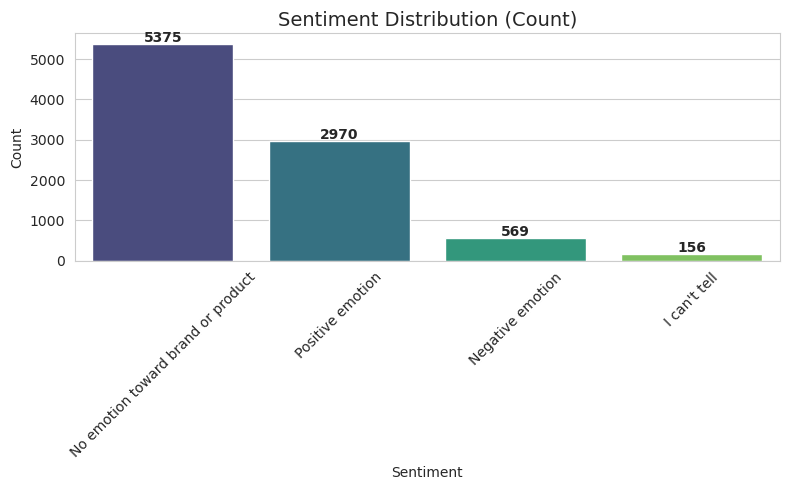

=== Class Distribution ===
                                    Count  Percentage
sentiment                                            
No emotion toward brand or product   5375        59.3
Positive emotion                     2970        32.7
Negative emotion                      569         6.3
I can't tell                          156         1.7


In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

sentiment_counts = df['sentiment'].value_counts()

sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values,
            ax=ax, palette='viridis')
ax.set_title('Sentiment Distribution (Count)', fontsize=14)
ax.set_xlabel('Sentiment')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(sentiment_counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('=== Class Distribution ===')
dist = pd.DataFrame({
    'Count': sentiment_counts,
    'Percentage': (sentiment_counts / len(df) * 100).round(1)
})
print(dist)

**Class Distribution Analysis:**

The dataset exhibits significant **class imbalance**:
- **Neutral** ("No emotion toward brand or product") dominates at ~60% of all tweets
- **Positive** ("Positive emotion") comprises ~33%
- **Negative** ("Negative emotion") is the minority at only ~6%
- **"I can't tell"** represents ~2% — these are ambiguous even to human raters

**Implications for modeling:**
1. A naive baseline predicting "neutral" for every tweet would achieve ~60% accuracy — **accuracy is therefore a misleading metric**
2. We will use **weighted F1-score** as our primary metric (accounts for class sizes)
3. We will use **class weights** (`class_weight='balanced'`) in our models
4. We will use **stratified train/test splits** to preserve class proportions
5. We will **drop "I can't tell"** rows since they represent annotator uncertainty, not a meaningful sentiment class

In [10]:
# Drop "I can't tell" — annotator uncertainty, not a meaningful class
cant_tell_count = df[df['sentiment'] == "I can't tell"].shape[0]
print(f'Removing {cant_tell_count} "I can\'t tell" rows '
      f'({cant_tell_count/len(df)*100:.1f}%)')

df = df[df['sentiment'] != "I can't tell"].copy()
print(f'Dataset after removal: {df.shape[0]} rows')
print(f'\nRemaining sentiment distribution:\n{df["sentiment"].value_counts()}')

Removing 156 "I can't tell" rows (1.7%)
Dataset after removal: 8914 rows

Remaining sentiment distribution:
sentiment
No emotion toward brand or product    5375
Positive emotion                      2970
Negative emotion                       569
Name: count, dtype: int64


In [11]:
# Descriptive statistics for text properties
df['tweet_length'] = df['tweet_text'].astype(str).str.len()
df['word_count'] = df['tweet_text'].astype(str).str.split().str.len()

print('=== Descriptive Statistics: Tweet Text Properties ===\n')
text_stats = df.groupby('sentiment')[['tweet_length', 'word_count']].agg(
    ['count', 'mean', 'std', 'min', 'median', 'max']
).round(1)
print(text_stats)

print(f'\n=== Overall Statistics ===')
print(f'Total tweets:          {len(df)}')
print(f'Mean tweet length:     {df["tweet_length"].mean():.1f} characters')
print(f'Mean word count:       {df["word_count"].mean():.1f} words')
print(f'Median tweet length:   {df["tweet_length"].median():.1f} characters')
print(f'Median word count:     {df["word_count"].median():.1f} words')

=== Descriptive Statistics: Tweet Text Properties ===

                                   tweet_length                               \
                                          count   mean   std min median  max   
sentiment                                                                      
Negative emotion                            569  109.4  27.4  38  114.0  158   
No emotion toward brand or product         5375  104.2  27.2  11  108.0  178   
Positive emotion                           2970  105.6  27.1  25  110.0  170   

                                   word_count                            
                                        count  mean  std min median max  
sentiment                                                                
Negative emotion                          569  18.7  5.1   6   19.0  31  
No emotion toward brand or product       5375  17.4  4.9   2   18.0  32  
Positive emotion                         2970  18.2  4.9   4   19.0  33  

=== Overall Statist

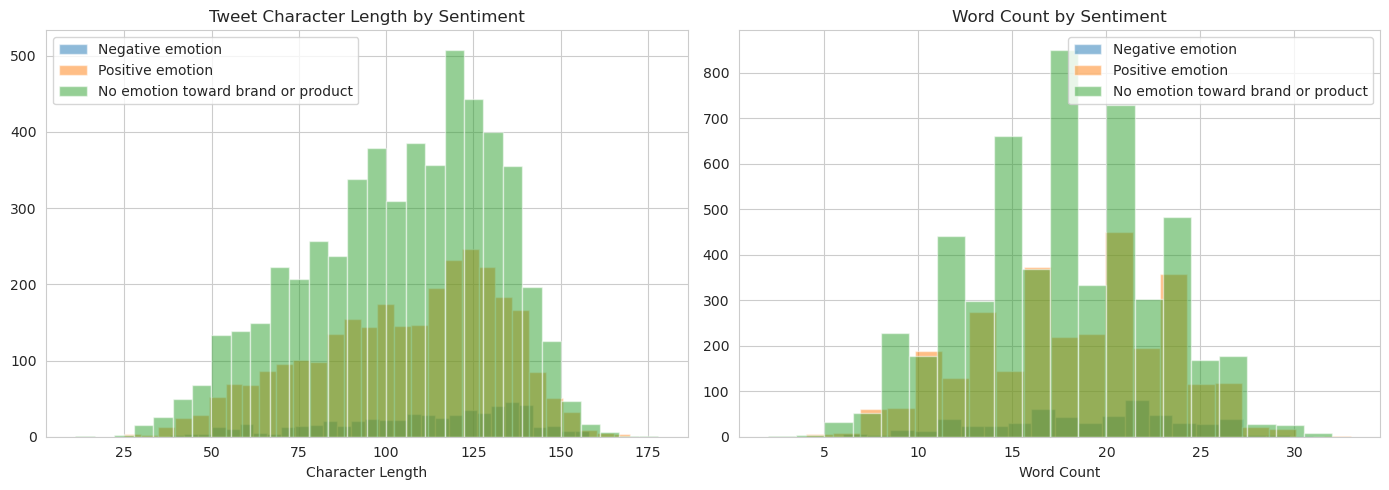

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for sentiment in df['sentiment'].unique():
    subset = df[df['sentiment'] == sentiment]
    axes[0].hist(subset['tweet_length'], alpha=0.5, label=sentiment, bins=30)
    axes[1].hist(subset['word_count'], alpha=0.5, label=sentiment, bins=20)

axes[0].set_title('Tweet Character Length by Sentiment')
axes[0].set_xlabel('Character Length')
axes[0].legend()
axes[1].set_title('Word Count by Sentiment')
axes[1].set_xlabel('Word Count')
axes[1].legend()
plt.tight_layout()
plt.show()

**Descriptive Statistics Insights:**

- Tweet lengths are relatively consistent across sentiment classes (most are 100–140 characters, reflecting Twitter's original character limit)
- There is **no strong length-based signal** separating sentiment classes — confirming that **content (word choice)** rather than **structure (length)** drives sentiment
- The similar distributions justify our focus on **text-based features** (TF-IDF, word embeddings)

### 3.5 Product/Brand Breakdown

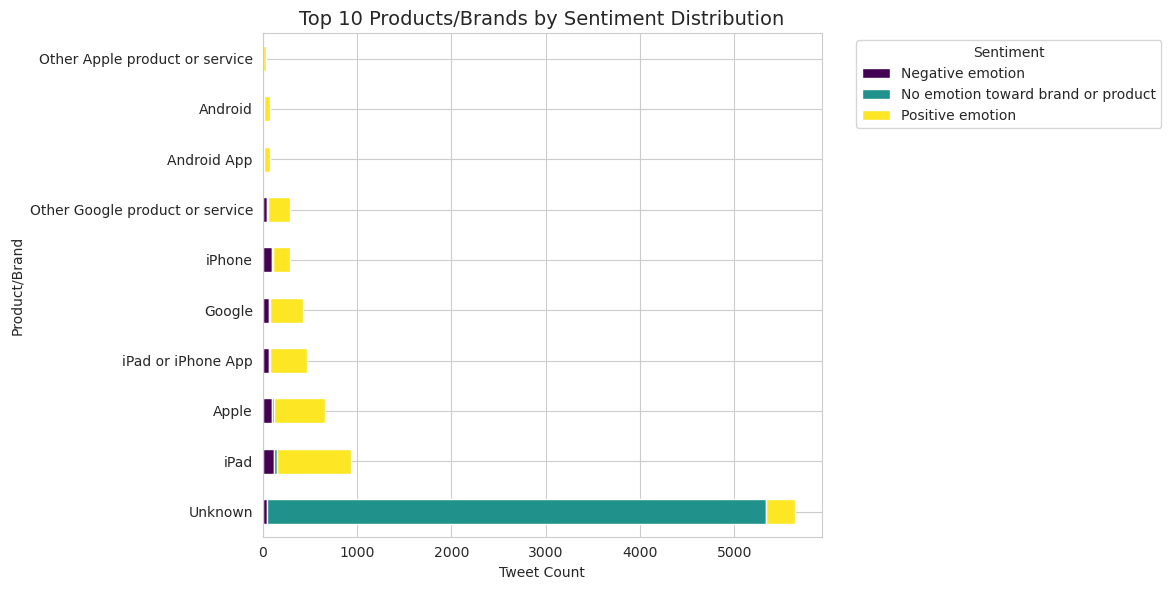


=== Sentiment by Product (Top 10) ===
sentiment                        Negative emotion  \
product                                             
Unknown                                        51   
iPad                                          125   
Apple                                          95   
iPad or iPhone App                             63   
Google                                         68   
iPhone                                        102   
Other Google product or service                47   
Android App                                     8   
Android                                         8   
Other Apple product or service                  2   

sentiment                        No emotion toward brand or product  \
product                                                               
Unknown                                                        5284   
iPad                                                             24   
Apple                                   

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))
product_sentiment = pd.crosstab(
    df['product'].fillna('Not specified'), df['sentiment']
)
product_top = product_sentiment.loc[
    product_sentiment.sum(axis=1).nlargest(10).index
]
product_top.plot(kind='barh', stacked=True, ax=ax, colormap='viridis')
ax.set_title('Top 10 Products/Brands by Sentiment Distribution', fontsize=14)
ax.set_xlabel('Tweet Count')
ax.set_ylabel('Product/Brand')
ax.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('\n=== Sentiment by Product (Top 10) ===')
print(product_top)


**Product Distribution Insights:**

- Many tweets have **no product specified** — these are general brand mentions
- **iPad** and **iPhone** related products dominate the Apple side
- **Google** products are more diffuse (Google Maps, Google Circles, etc.)
- The `product` column will **not** be used as a model feature because:
  1. It would cause the model to learn brand-specific associations rather than generalizable sentiment patterns
  2. Many values are missing
  3. In a production system, we wouldn't know the product before classification
  
However, this breakdown is valuable for **post-hoc analysis** — after building the model, we can examine which products receive the most negative sentiment.

---

## 4. Data Preparation

Text data requires specialized preprocessing. Raw tweets contain noise (URLs, @mentions, special characters) that doesn't carry sentiment information and would confuse our model. Our preprocessing pipeline is designed to:

1. **Remove noise** — URLs, @mentions, hashtag symbols, special characters
2. **Normalize text** — lowercase everything for consistency
3. **Tokenize** — split text into individual words
4. **Remove stopwords selectively** — remove common words EXCEPT negation terms ("not", "no", "never", etc.) because these flip sentiment
5. **Lemmatize** — reduce words to base forms ("running" → "run")

**Libraries used:**
- `NLTK` — tokenization, stopword list, lemmatization (fine-grained control over preprocessing)
- `re` (regex) — pattern-based text cleaning
- `scikit-learn TfidfVectorizer` — converting text to numerical features

In [14]:
# Drop rows with missing tweet text or sentiment
print(f'Rows before dropping nulls: {len(df)}')
df = df.dropna(subset=['tweet_text', 'sentiment'])
print(f'Rows after dropping nulls: {len(df)}')

# Define negation words to KEEP (they carry sentiment information)
negation_words = {
    'not', 'no', 'nor', 'never', 'neither', 'nobody', 'nothing',
    'nowhere', 'hardly', 'barely', 'scarcely', "don't", "doesn't",
    "didn't", "wasn't", "weren't", "won't", "wouldn't", "couldn't",
    "shouldn't", "can't", "cannot", "isn't", "aren't", "haven't",
    "hasn't"
}

# Custom stopwords: standard stopwords MINUS negation words
stop_words = set(stopwords.words('english')) - negation_words

lemmatizer = WordNetLemmatizer()


def preprocess_tweet(text):
    """
    Clean and preprocess a tweet for NLP analysis.

    Steps:
        1. Lowercase
        2. Remove URLs
        3. Remove @mentions
        4. Remove hashtag symbols (keep the word)
        5. Remove special characters and numbers
        6. Tokenize
        7. Remove stopwords (keeping negation words)
        8. Lemmatize

    Parameters
    ----------
    text : str
        Raw tweet text.

    Returns
    -------
    str
        Cleaned, tokenized, and lemmatized text.
    """
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [
        lemmatizer.lemmatize(token) for token in tokens
        if token not in stop_words and len(token) > 1
    ]
    return ' '.join(tokens)


df['clean_text'] = df['tweet_text'].apply(preprocess_tweet)

print('\n=== Preprocessing Examples ===')
for i in range(5):
    print(f'\nOriginal:  {df["tweet_text"].iloc[i]}')
    print(f'Cleaned:   {df["clean_text"].iloc[i]}')

Rows before dropping nulls: 8914
Rows after dropping nulls: 8914

=== Preprocessing Examples ===

Original:  .@wesley83 I have a 3G iPhone. After 3 hrs tweeting at #RISE_Austin, it was dead!  I need to upgrade. Plugin stations at #SXSW.
Cleaned:   iphone hr tweeting riseaustin dead need upgrade plugin station sxsw

Original:  @jessedee Know about @fludapp ? Awesome iPad/iPhone app that you'll likely appreciate for its design. Also, they're giving free Ts at #SXSW
Cleaned:   know awesome ipadiphone app youll likely appreciate design also theyre giving free t sxsw

Original:  @swonderlin Can not wait for #iPad 2 also. They should sale them down at #SXSW.
Cleaned:   not wait ipad also sale sxsw

Original:  @sxsw I hope this year's festival isn't as crashy as this year's iPhone app. #sxsw
Cleaned:   hope year festival isnt crashy year iphone app sxsw

Original:  @sxtxstate great stuff on Fri #SXSW: Marissa Mayer (Google), Tim O'Reilly (tech books/conferences) &amp; Matt Mullenweg (Wordpres

**Why these preprocessing choices?**
- **Keeping negation words** is critical. "This phone is not good" has opposite sentiment to "This phone is good" — removing "not" destroys this distinction.
- **Lemmatization over stemming** because lemmatization produces real words (better interpretability), while stemming produces fragments (e.g., "studi" from "studies").
- **Removing URLs and @mentions** because they're noise — they don't carry sentiment about the product itself.

In [15]:
print(f'Rows before removing empty clean_text: {len(df)}')
df = df[df['clean_text'].str.strip().str.len() > 0].copy()
print(f'Rows after removing empty clean_text: {len(df)}')
print(f'\nFinal sentiment distribution:\n{df["sentiment"].value_counts()}')

Rows before removing empty clean_text: 8914
Rows after removing empty clean_text: 8914

Final sentiment distribution:
sentiment
No emotion toward brand or product    5375
Positive emotion                      2970
Negative emotion                       569
Name: count, dtype: int64



## 4b. Advanced Data Preparation

Beyond basic text cleaning, we engineer additional features and use unsupervised techniques to better understand and represent our data.

**Advanced techniques:**
1. **Feature Engineering** — Extract metadata from tweets (punctuation, capitalization, lexicon hints)
2. **Unsupervised Clustering (K-Means)** — Explore natural groupings in TF-IDF space
3. **Pipeline Architecture** — Combine TF-IDF + engineered features using `ColumnTransformer` + `Pipeline`

=== Engineered Features Summary ===
       exclamation_count  question_count  ellipsis_count  caps_ratio  \
count            8914.00         8914.00         8914.00     8914.00   
mean                0.27            0.18            0.07        0.08   
std                 0.64            0.52            0.27        0.05   
min                 0.00            0.00            0.00        0.00   
25%                 0.00            0.00            0.00        0.04   
50%                 0.00            0.00            0.00        0.07   
75%                 0.00            0.00            0.00        0.11   
max                 9.00           11.00            3.00        0.78   

       all_caps_words  char_length  avg_word_length  hashtag_count  \
count         8914.00      8914.00          8914.00        8914.00   
mean             1.09       104.98             5.03           1.75   
std              1.03        27.19             0.80           1.09   
min              0.00        11.00 

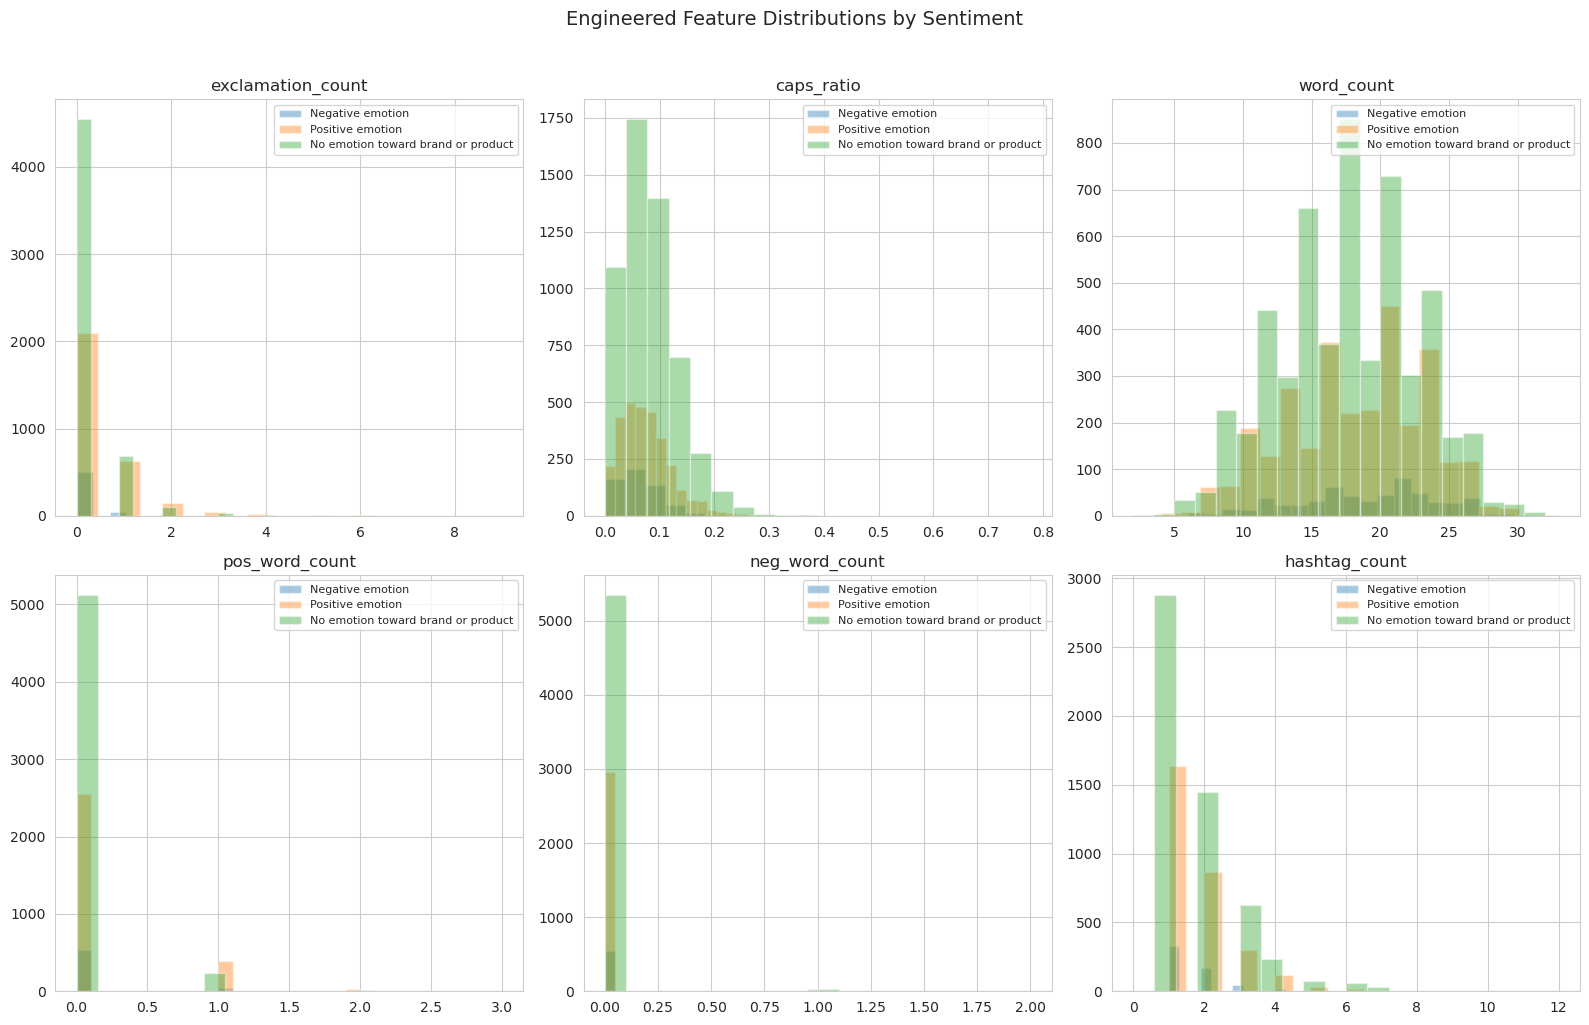

In [16]:
def extract_features(dataframe, text_col='tweet_text'):
    """
    Engineer numeric features from raw tweet text.

    Captures stylistic and structural signals correlated with sentiment:
    punctuation patterns, capitalization, and simple lexicon matches.

    Parameters
    ----------
    dataframe : pd.DataFrame
        DataFrame containing the text column.
    text_col : str
        Name of the column with raw tweet text.

    Returns
    -------
    pd.DataFrame
        Original DataFrame with new engineered feature columns.
    """
    df_feat = dataframe.copy()
    raw = df_feat[text_col].astype(str)

    # Punctuation features
    df_feat['exclamation_count'] = raw.str.count('!')
    df_feat['question_count'] = raw.str.count(r'\?')
    df_feat['ellipsis_count'] = raw.str.count(r'\.\.\.')

    # Capitalization features
    df_feat['caps_ratio'] = raw.apply(
        lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1)
    )
    df_feat['all_caps_words'] = raw.apply(
        lambda x: sum(1 for w in x.split() if w.isupper() and len(w) > 1)
    )

    # Length features
    df_feat['char_length'] = raw.str.len()
    df_feat['avg_word_length'] = raw.apply(
        lambda x: np.mean([len(w) for w in x.split()])
        if len(x.split()) > 0 else 0
    )

    # Social media features
    df_feat['hashtag_count'] = raw.str.count('#')
    df_feat['mention_count'] = raw.str.count('@')
    df_feat['url_count'] = raw.str.count(r'http|www|\{link\}')

    # Sentiment lexicon hints
    pos_words = {
        'love', 'great', 'awesome', 'amazing', 'best',
        'good', 'happy', 'excellent', 'fantastic', 'beautiful'
    }
    neg_words = {
        'hate', 'bad', 'worst', 'terrible', 'awful',
        'poor', 'broken', 'crash', 'fail', 'ugly'
    }
    df_feat['pos_word_count'] = raw.str.lower().apply(
        lambda x: sum(1 for w in x.split() if w in pos_words)
    )
    df_feat['neg_word_count'] = raw.str.lower().apply(
        lambda x: sum(1 for w in x.split() if w in neg_words)
    )
    return df_feat


df = extract_features(df)

engineered_features = [
    'exclamation_count', 'question_count', 'ellipsis_count',
    'caps_ratio', 'all_caps_words', 'char_length', 'avg_word_length',
    'hashtag_count', 'mention_count', 'url_count',
    'pos_word_count', 'neg_word_count'
]

print('=== Engineered Features Summary ===')
print(df[engineered_features].describe().round(2))

# Visualize feature distributions by sentiment
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
plot_features = [
    'exclamation_count', 'caps_ratio', 'word_count',
    'pos_word_count', 'neg_word_count', 'hashtag_count'
]
for ax, feat in zip(axes.flatten(), plot_features):
    for sentiment in df['sentiment'].unique():
        subset = df[df['sentiment'] == sentiment][feat]
        ax.hist(subset, alpha=0.4, label=sentiment, bins=20)
    ax.set_title(feat)
    ax.legend(fontsize=8)

plt.suptitle('Engineered Feature Distributions by Sentiment',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Feature Engineering Rationale:**
- **Exclamation marks & caps ratio** — Strong emotions (both positive and negative) use more exclamation marks and capitalization, helping separate emotional from neutral tweets.
- **Positive/negative word counts** — Simple lexicon features act as a "hint" complementary to TF-IDF.
- **Hashtag and mention density** — Tweets primarily sharing links/mentions tend to be neutral/informational.

SVD explained variance: 0.033


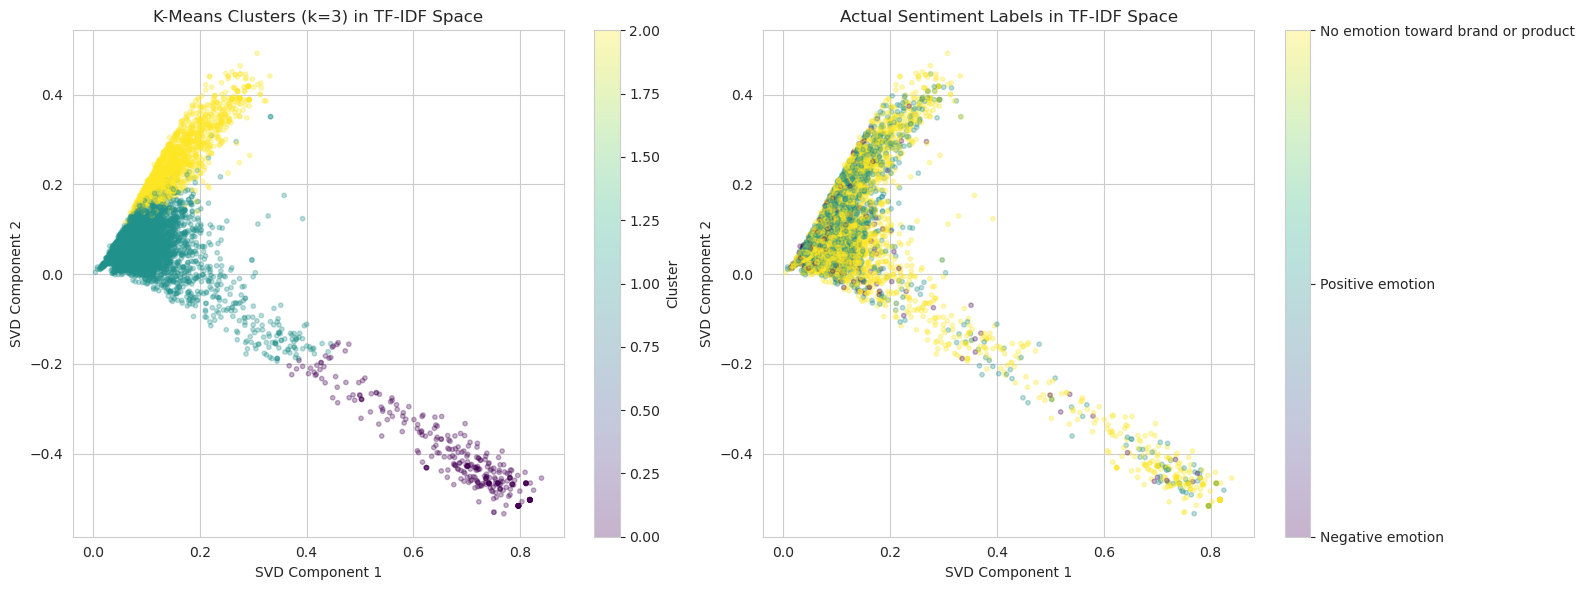


=== Cluster vs Sentiment Cross-Tabulation ===
sentiment  Negative emotion  No emotion toward brand or product  \
row_0                                                             
0                        11                                 251   
1                       516                                4246   
2                        42                                 878   
All                     569                                5375   

sentiment  Positive emotion   All  
row_0                              
0                        64   326  
1                      2368  7130  
2                       538  1458  
All                    2970  8914  


In [17]:
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD

# Unsupervised Analysis: K-Means Clustering on TF-IDF space
tfidf_cluster = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2)
X_tfidf_all = tfidf_cluster.fit_transform(df['clean_text'])

# Reduce dimensions with TruncatedSVD for visualization
svd = TruncatedSVD(n_components=2, random_state=42)
X_svd = svd.fit_transform(X_tfidf_all)
print(f'SVD explained variance: {svd.explained_variance_ratio_.sum():.3f}')

# K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_tfidf_all)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(
    X_svd[:, 0], X_svd[:, 1], c=cluster_labels,
    cmap='viridis', alpha=0.3, s=10
)
axes[0].set_title('K-Means Clusters (k=3) in TF-IDF Space', fontsize=12)
axes[0].set_xlabel('SVD Component 1')
axes[0].set_ylabel('SVD Component 2')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

sentiment_map = {
    label: i for i, label in enumerate(df['sentiment'].unique())
}
sentiment_numeric = df['sentiment'].map(sentiment_map)
scatter2 = axes[1].scatter(
    X_svd[:, 0], X_svd[:, 1], c=sentiment_numeric,
    cmap='viridis', alpha=0.3, s=10
)
axes[1].set_title('Actual Sentiment Labels in TF-IDF Space', fontsize=12)
axes[1].set_xlabel('SVD Component 1')
axes[1].set_ylabel('SVD Component 2')
cbar = plt.colorbar(scatter2, ax=axes[1])
cbar.set_ticks(list(sentiment_map.values()))
cbar.set_ticklabels(list(sentiment_map.keys()))

plt.tight_layout()
plt.show()

ct = pd.crosstab(cluster_labels, df['sentiment'], margins=True)
print('\n=== Cluster vs Sentiment Cross-Tabulation ===')
print(ct)

**Unsupervised Clustering Insight:**

K-Means on TF-IDF space reveals whether sentiment classes are naturally separable. If clusters don't align perfectly with sentiment labels, it tells us:
1. The sentiment boundary is **non-linear** — motivating more complex models
2. Neutral and positive tweets overlap heavily in vocabulary
3. Our **engineered features** may provide additional signal to separate overlapping clusters

This unsupervised analysis serves as an **exploratory diagnostic** that validates our modeling approach.

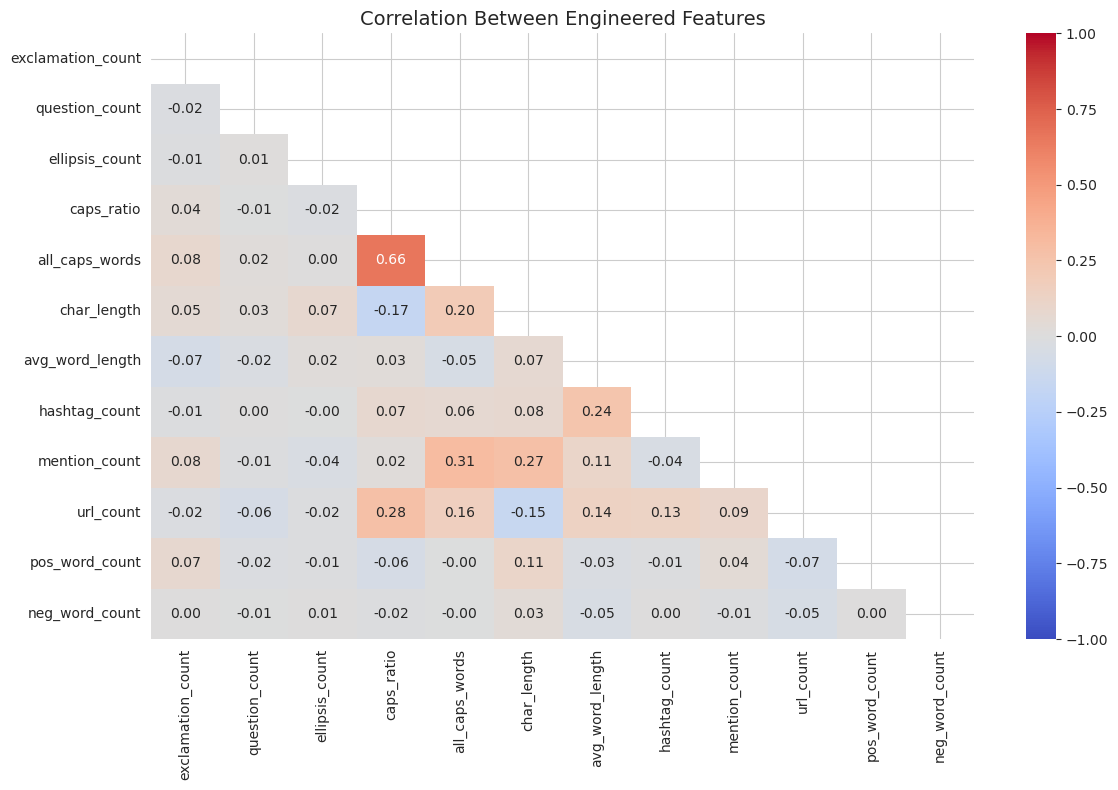


Highly correlated pairs (|r| > 0.7):


In [18]:
# Feature correlation analysis
fig, ax = plt.subplots(figsize=(12, 8))
corr_matrix = df[engineered_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, ax=ax, vmin=-1, vmax=1
)
ax.set_title('Correlation Between Engineered Features', fontsize=14)
plt.tight_layout()
plt.show()

print('\nHighly correlated pairs (|r| > 0.7):')
for i in range(len(corr_matrix)):
    for j in range(i + 1, len(corr_matrix)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            print(f'  {corr_matrix.index[i]} <-> '
                  f'{corr_matrix.columns[j]}: '
                  f'{corr_matrix.iloc[i, j]:.3f}')